 # DEAD-TIME AND AFTERPULSING MEASUREMENTS (Autocorrelation)
 
  When a SPAD detects a photon, it undergoes an avalanche and must physically quench and recharge. During this "dead time," it is totally blind. Furthermore, sometimes a charge gets trapped in the silicon lattice and releases a few nanoseconds later, causing a fake "afterpulse" click. If we run a tt.Correlation where the Start channel and Stop channel are the exact same SPAD (e.g., Ch 1 vs Ch 1), the resulting histogram will show strictly 0 counts for the duration of the deadtime (proving your dead time, usually 20-50 ns). Right after the dead time ends, if there is a spike before the data flattens out, that is a measure of afterpulsing.


## Measurement
Correlation measurements on the same SPAD. ```tt.Correlation()``` will time stamp a stream of events for ```MEASURE_TIME_PS``` , calculate the time differences and sort them in ```N_BINS``` of a given width. This measurement, also known as correlation $G^{(2)}(\tau)$, yields information about the probability of detecting a photon $\tau$ seconds after detecting a previus photon. 

In [ ]:
import TimeTagger as tt
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:

# --- EXPERIMENTAL PARAMETERS ---
SPAD1_CH = 1
SPAD2_CH = 2
BIN_WIDTH_PS = 100
N_BINS = 2000
MEASURE_TIME_PS = int(10e12) # 10 seconds

print("Connecting to Time Tagger...")
tagger = tt.createTimeTagger()

# 1. Initialize BOTH measurements first
print("Initializing hardware channels...")
autocorr1 = tt.Correlation(tagger, channel_1=SPAD1_CH, channel_2=SPAD1_CH, binwidth=BIN_WIDTH_PS, n_bins=N_BINS)
autocorr2 = tt.Correlation(tagger, channel_1=SPAD2_CH, channel_2=SPAD2_CH, binwidth=BIN_WIDTH_PS, n_bins=N_BINS)

# 2. Trigger them simultaneously 
# (Calling startFor back-to-back starts them in parallel in the backend)
print("Accumulating data ...")
autocorr1.startFor(MEASURE_TIME_PS, clear=True)
autocorr2.startFor(MEASURE_TIME_PS, clear=True)

# 3. Halt Python until BOTH are finished
autocorr1.waitUntilFinished()
autocorr2.waitUntilFinished()

# 4. Fetch the data arrays
y_counts1 = autocorr1.getData()
x_time = autocorr1.getIndex() # X-axis is identical for both, we only need to pull it once

y_counts2 = autocorr2.getData()

# 5. Release hardware immediately
tt.freeTimeTagger(tagger)
print("Hardware released.")


## Save Data

In [ ]:
# Data folder path 
data_folder = "../data/raw/deadtime_afterpulsing"
#os.makedirs(data_folder, exist_ok=True)

 # Saving all arrays. (save the X-axis once)
np.save(f"{data_folder}/autocorr_time_ps.npy", x_time)
np.save(f"{data_folder}/autocorr_spad1_counts_exposed5.npy", y_counts1) #Write name for file. 
np.save(f"{data_folder}/autocorr_spad2_counts_exposed5.npy", y_counts2) #Write name for file. 
print(f"Data saved to: {os.path.abspath(data_folder)}")


Data saved to: c:\Users\Eng Barroso\DevEB\Projects\python-scripts\spad-measurements\data


# DATA ANALYSIS
* Dead Time analysis. 
* Afterpulsing 

In [1]:
import TimeTagger as tt
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# Load data 
data_dir = "../data/raw/deadtime_afterpulsing"   # Directory relative to this file. 

time_file = "autocorr_time_ps.npy"

spad1_files = [
    "autocorr_spad1_counts_exposed1.npy",
    "autocorr_spad1_counts_exposed2.npy",
    "autocorr_spad1_counts_exposed3.npy",
    "autocorr_spad1_counts_exposed4.npy"
]   # Identify Data for SPAD A 

spad2_files = [
    "autocorr_spad2_counts_exposed1.npy",
    "autocorr_spad2_counts_exposed2.npy",
    "autocorr_spad2_counts_exposed3.npy",
    "autocorr_spad2_counts_exposed4.npy"
]   # Identify Data for SPAD B

## Dead Time
Extract deadtime from all spad files, calculate the mean deadtime and the maximum countrate for the SPADs. 

In [3]:
# Dead Time Calculation 
def extract_dead_time(file_list, channel_name, time_list_name, data_dir):
    dead_times_ns = []
    time_list = np.load(os.path.join(data_dir,time_list_name))
    
    for filename in file_list:
        filepath = os.path.join(data_dir, filename)
        counts = np.load(filepath)          
        
        # Find t=0 coincidence peak
        peak_idx = np.argmax(counts)
        
        # 2. Find index where counts drop to zero AFTER the peak
        # np.argmax returns the first True value
        zero_offset = np.argmax(counts[peak_idx:] == 0) 
        start_search_idx = peak_idx + zero_offset
        
        # Slice the arrays starting from that exact zero-bin
        x_search = time_list[start_search_idx:]
        counts_search = counts[start_search_idx:]
        
        # Find the first bin where the SPAD wakes up
        wakeup_idx = np.argmax(counts_search > 0)
        
        # Extract time and convert to ns
        dead_time_ps = x_search[wakeup_idx]
        dead_time_ns = dead_time_ps / 1000.0
        dead_times_ns.append(dead_time_ns)
        
    # Results      
    mean_dt_ns = np.mean(dead_times_ns)
    std_dt_ns = np.std(dead_times_ns)
    
    max_freq_hz = 1 / (mean_dt_ns * 1e-9) 
    max_freq_mhz = max_freq_hz / 1e6
    
    print(f"=== {channel_name} ===")
    print(f"Measured Dead Times (ns): {[round(dt, 2) for dt in dead_times_ns]}")
    print(f"Mean Dead Time:           {mean_dt_ns:.2f} ns ± {std_dt_ns:.2f} ns")
    print(f"Max Theoretical Rate:     {max_freq_mhz:.2f} MHz\n")

    return start_search_idx, dead_time_ps, time_list, counts, mean_dt_ns

idx_s1, wake1, x_time, y_counts1, mean_dt1 = extract_dead_time(spad1_files, 'SPAD 1', time_file, data_dir)
idx_s2, wake2, x_time, y_counts2, mean_dt2 = extract_dead_time(spad2_files, 'SPAD 2', time_file, data_dir)

=== SPAD 1 ===
Measured Dead Times (ns): [np.float64(4.8), np.float64(5.1), np.float64(4.9), np.float64(4.8)]
Mean Dead Time:           4.90 ns ± 0.12 ns
Max Theoretical Rate:     204.08 MHz

=== SPAD 2 ===
Measured Dead Times (ns): [np.float64(4.8), np.float64(5.0), np.float64(4.8), np.float64(4.8)]
Mean Dead Time:           4.85 ns ± 0.09 ns
Max Theoretical Rate:     206.19 MHz



Select `dataset` from: `autocorr_spad1_counts_exposed1`, `autocorr_spad1_counts_exposed4` . or `autocorr_spad1_counts_covered1` or `autocorr_spadA_counts_01_0_OD0.6`. 

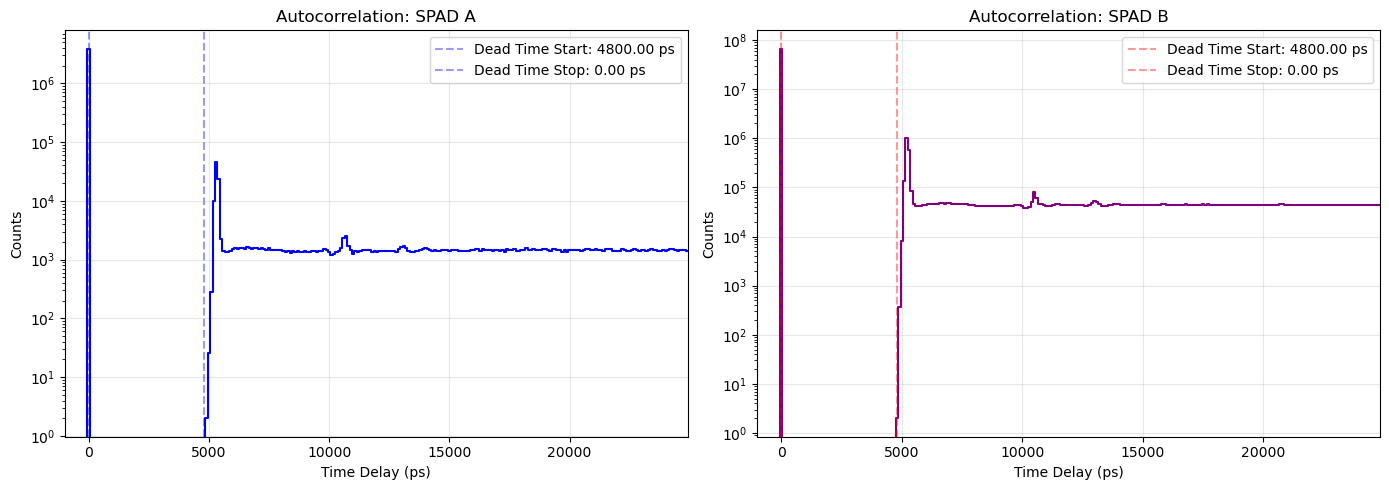

In [8]:
# Select dataset
dataset = "autocorr_spadA_counts_01_0_OD0.6.npy"
y_counts1 = np.load(os.path.join(data_dir,dataset))
x_time = np.load(os.path.join(data_dir,time_file))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)) 

# 1st Plot
ax1.plot(x_time, y_counts1, drawstyle='steps-mid', color='blue')

# Plot the vertical lines for Dead Time
ax1.axvline(x= wake1, color='blue', linestyle='--', alpha = 0.4 ,label=f'Dead Time Start: {wake1:.2f} ps')
ax1.axvline(x= x_time[idx_s1-1] , color='blue', alpha = 0.4, linestyle = '--', label=f'Dead Time Stop: { x_time[idx_s1-1]:.2f} ps')

ax1.set_xlabel('Time Delay (ps)')
ax1.set_ylabel('Counts')
ax1.set_title(f'Autocorrelation: SPAD A')
ax1.set_yscale('log')

# Set X-limit to show the dead time line plus a 20 ns buffer
ax1.set_xlim(-1000, (mean_dt1 * 1000) + 20000) 
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# 2nd Plot
ax2.plot(x_time, y_counts2, drawstyle='steps-mid', color='purple')

# Plot the vertical lines for Dead Time
ax2.axvline(x= wake2, color='red', linestyle='--', alpha = 0.4 ,label=f'Dead Time Start: {wake2:.2f} ps')
ax2.axvline(x= x_time[idx_s2-1] , color='red', alpha = 0.4, linestyle = '--', label=f'Dead Time Stop: { x_time[idx_s2-1]:.2f} ps')

ax2.set_xlabel('Time Delay (ps)')
ax2.set_ylabel('Counts')
ax2.set_title(f'Autocorrelation: SPAD B')
ax2.set_yscale('log')

# Set X-limit 
ax2.set_xlim(-1000, (mean_dt2 * 1000) + 20000) 
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

plt.tight_layout() 
plt.show()

## Afterpulsing

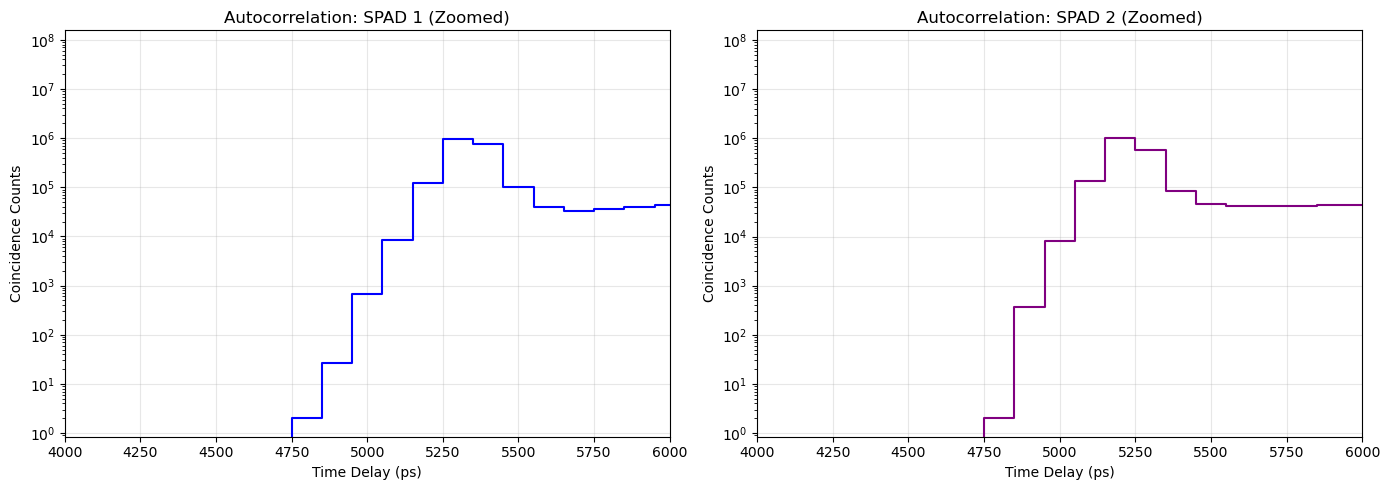

In [ ]:
# Afterpulsing
# Uses x_time, y_counts1, y_counts2 from the previous dead-time calculation. 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)) 

# SPAD 1 Plot
ax1.plot(x_time, y_counts1, drawstyle='steps-mid', color='blue')
ax1.set_xlabel('Time Delay (ps)')
ax1.set_ylabel('Coincidence Counts')
ax1.set_title('Autocorrelation: SPAD 1 (Zoomed)')
ax1.set_yscale('log')
ax1.set_xlim(4000, 6000) # Zoomed to view recovery peak and baseline
ax1.grid(True, alpha=0.3)

# SPAD 2 Plot
ax2.plot(x_time, y_counts2, drawstyle='steps-mid', color='purple')
ax2.set_xlabel('Time Delay (ps)')
ax2.set_ylabel('Coincidence Counts')
ax2.set_title('Autocorrelation: SPAD 2 (Zoomed)')
ax2.set_yscale('log')
ax2.set_xlim(4000, 6000) 
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def calculate_afterpulsing(time_array, counts_array, peak_start, peak_end, baseline_start, label):
    # Create the logical masks
    peak_mask = (time_array >= peak_start) & (time_array <= peak_end)
    baseline_mask = (time_array >= baseline_start)

    # Total avalanches is the massive peak at exactly t=0
    N_total = counts_array[time_array == 0][0]

    # Calculate the average baseline noise per bin
    C_base = np.mean(counts_array[baseline_mask])

    # Sum the raw counts in the afterpulsing peak window
    raw_peak_sum = np.sum(counts_array[peak_mask])

    # Subtract the baseline noise hiding under the peak
    num_peak_bins = np.sum(peak_mask)
    N_ap = raw_peak_sum - (C_base * num_peak_bins)

    # Calculate Probability
    P_ap = (N_ap / N_total) * 100

    # Print nicely formatted results
    print(f"=== {label} ===")
    print(f"Integration Window:         {peak_start} ps to {peak_end} ps")
    print(f"Total Avalanches (N_total): {N_total:,}")
    print(f"Average Baseline per bin:   {C_base:.2f}")
    print(f"Pure Afterpulses (N_ap):    {N_ap:,.0f}")
    print(f"-----------------------------------")
    print(f"Afterpulsing Probability:   {P_ap:.4f} % \n")

    return P_ap

# Adjust these based on visual inspection of the plots above
peak_start_ps = 4750 
peak_end_ps = 5550   
baseline_start_ps = 6000

# Run for both SPADs
P_ap_1 = calculate_afterpulsing(x_time, y_counts1, peak_start_ps, peak_end_ps, baseline_start_ps, "SPAD 1")
P_ap_2 = calculate_afterpulsing(x_time, y_counts2, peak_start_ps, peak_end_ps, baseline_start_ps, "SPAD 2")


=== SPAD 1 ===
Integration Window:         4750 ps to 5550 ps
Total Avalanches (N_total): 65,508,437
Average Baseline per bin:   42436.38
Pure Afterpulses (N_ap):    1,577,244
-----------------------------------
Afterpulsing Probability:   2.4077 % 

=== SPAD 2 ===
Integration Window:         4750 ps to 5550 ps
Total Avalanches (N_total): 66,067,275
Average Baseline per bin:   43708.34
Pure Afterpulses (N_ap):    1,522,295
-----------------------------------
Afterpulsing Probability:   2.3042 % 

